In [1]:
# === Configuración para importar módulos locales ===
import sys
from pathlib import Path

src_path = Path().resolve().parent / "src"
sys.path.append(str(src_path))

print(f"✅ Módulos importados desde: {src_path}")

✅ Módulos importados desde: /home/mariajose/proc-icdv/src


In [11]:
import numpy as np
import pandas as pd

In [3]:
import processing as pr
import deriv as dr
import plotting as pl
import fitting as ft

In [4]:
# --- carga de datos ---
path_json = "../tmp/NMC-20.json"
dict_ciclos_sep = pr.cargar_json(path_json)
indices_ciclos = list(dict_ciclos_sep.keys())

Estructura: dict_ciclos_sep = {ciclo: {"Ch": df_ciclo_ch, "Dis": df_ciclo_dis}}
Total de ciclos en el JSON: 301


In [5]:
# --- Selección de ciclos ---
ciclos_sel = pr.seleccionar_ciclos(
    dict_ciclos_sep,
    rango=(21, 300),
    excluir={30, 32, 34, 35, 38, 88, 186, 187, 188, 189, 190, 191, 192, 193, 202, 247},
)

✅ 90 ciclos seleccionados
   → [21, 24, 27, 33, 36, 39, 42, 45, 48, 51]...


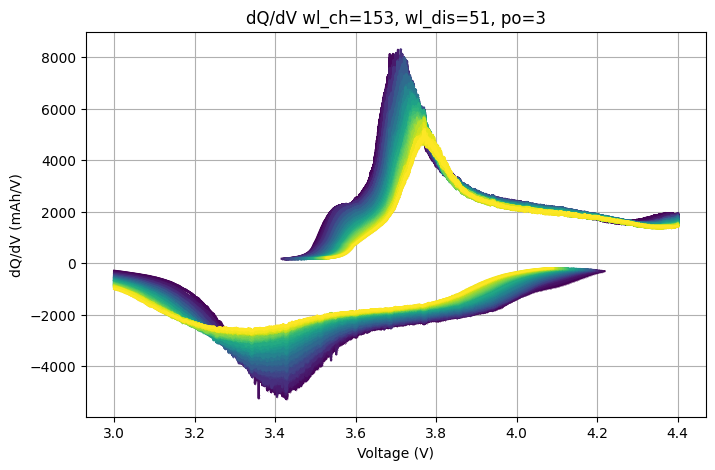

"\ndiccio = {21: {'Ch': df_ch_21, 'Dis': df_dis_21},\n        99: {'Ch': df_ch_99, 'Dis': df_dis_99},\n        ...: {...}}\n"

In [6]:
# --- Trunco datos y calculo derivada ---

# Para NMC-20:
# charge (wl = 153, truncar los n=30 puntos iniciales)
# discharge (wl = 51 = 153 / 3, truncar los n=10=30/3 puntos finales)
# Esto se debe a que la señal de carga tiene 3 veces mas resolución que la de descarga.
# Estos valores pueden cambiar según el dataset.

diccio = dr.truncar_señal(ciclos_sel, dict_ciclos_sep, n_dis=10, n_ch=30)
diccio =  dr.plot_dqdV(ciclos_sel, diccio)

'''
diccio = {21: {'Ch': df_ch_21, 'Dis': df_dis_21},
        99: {'Ch': df_ch_99, 'Dis': df_dis_99},
        ...: {...}}
'''
# --- Exportar a csv para trabajar en Origin ---
#dict[21]['Ch'].to_csv(output_folder / 'df_ch_21.csv', index=False)
#dict[21]['Dis'].to_csv(output_folder / 'df_dis_21.csv', index=False)

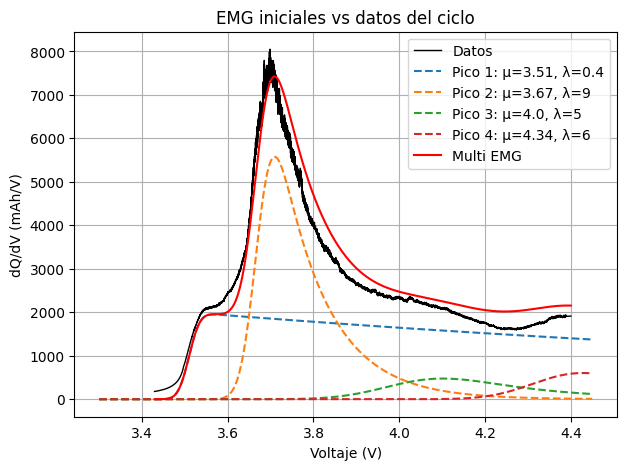

In [7]:
# --- Pruebo manualmente guess inicial para parametros de ajuste ---

# En la EMG los parámetros son: (amplitud, media, sigma, lambda)

df_ch = diccio[21]['Ch']
param_guess = [(5000, 3.51, 0.02, 0.4), 
               (1000, 3.67, 0.03, 9), 
               (200, 4.0, 0.1, 5), 
               (220, 4.34, 0.09, 6)]


ft.plot_emg_guess(df_ch, param_guess)

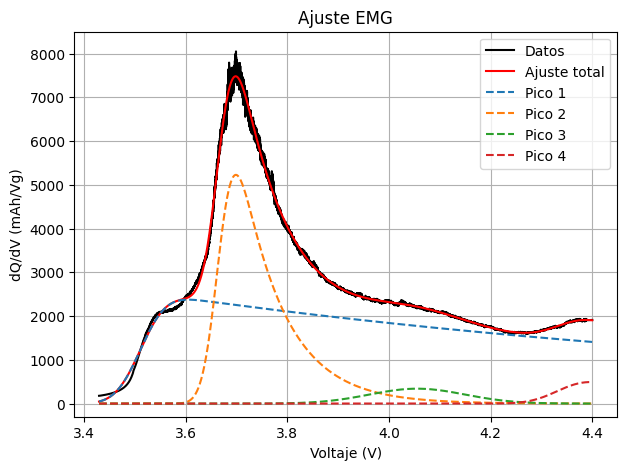

In [9]:
# --- Test de ajuste del primer ciclo ---

# Parámetros iniciales por pico
p_ini_peaks = [
    (5000, 3.51, 0.02, 0.4),
    (1000, 3.67, 0.03, 9),
    (200, 4.0, 0.1, 5),
    (220, 4.34, 0.09, 6)
]

n_peaks = len(p_ini_peaks)

# Construir p_ini_emg y bounds automáticamente
p_ini_emg = []
lb, ub = [], []

for a0, mu0, sigma0, lam0 in p_ini_peaks:
    p_ini_emg += [a0, mu0, sigma0, lam0]
    lb += [0, mu0-0.05, 1e-6, 0]
    ub += [np.inf, mu0+0.05, np.inf, lam0*10]

bounds_emg = (lb, ub)

# Ajuste del ciclo 21 de carga
df_ch_21 = diccio[21]['Ch']
p_opt_21, cov_21 = ft.fit_emg_ciclo(df_ch_21, p_ini_emg, bounds_emg)
ft.plot_emg_fit(df_ch_21, p_opt_21)

In [ ]:
# --- Ajuste de múltiples ciclos ---

# ---- Elegir ciclos del loop y nombre del .csv ------------------------------------------------
#nombre = 'EMG_betterguess2'
#ciclos_sel = ciclos_sel  # ciclos seleccionados previamente
#ciclos_grafico = [21, 99, 198, 297, 396, 498, 597, 696, 795, 897]
# ------------------------------------------------------------------------------------------------

#TODO: arreglar fitloop_emg_lamfijo para que si falla agregue NaNs en vez de romper todo
#y poder guardar los resultados parciales. Fijarse en como se hace en estudio7.

#parametros, covs = ft.fitloop_emg_lamfijo(
#    diccio,
#    ciclos=ciclos_sel,
#    p_ini_emg=p_ini_emg,
#    bounds_emg=bounds_emg,
#    ciclos_grafico=ciclos_grafico
#)

#ft.guardar_parametros_emg(parametros, ciclos_sel, nombre)

In [ ]:
# --- Trabajo con parámetros previamente ajustados ---

df_param = pd.read_csv("../output/parametros_ajustes_EMG_betterguess2.csv", index_col=0)
df_param.head()

,a1,mu1,sigma1,lambda1,a2,mu2,sigma2,lambda2,a3,mu3,sigma3,lambda3,a4,mu4,sigma4,lambda4
21,3814.877717,3.511462,0.039376,0.669109,747.967441,3.666574,0.024883,11.536278,80.481496,4.036149,0.092128,50.0,120.287143,4.341188,0.046258,7.14122
24,3799.246576,3.511889,0.035449,0.669109,746.743376,3.664647,0.027371,11.536278,77.633145,4.026145,0.101341,50.0,114.381614,4.335409,0.041632,7.14122
27,3665.159221,3.514373,0.034002,0.669109,782.886043,3.665219,0.024634,11.536278,85.396460,4.030225,0.091207,50.0,124.154815,4.339357,0.045795,7.14122
33,3797.668553,3.516411,0.034489,0.669109,741.804301,3.669148,0.024413,11.536278,84.806658,4.020258,0.095836,50.0,117.839388,4.361507,0.041216,7.14122
36,3731.637202,3.514570,0.031040,0.669109,758.659536,3.669005,0.025663,11.536278,93.287324,4.049256,0.095266,50.0,129.622262,4.359309,0.043571,7.14122


In [18]:
# --- Plot de un ciclo en particular ---

# ------ Elegir cuál y de qué loop ---------------
ciclo = 300
df_param = pd.read_csv("../output/parametros_ajustes_EMG_betterguess2.csv", index_col=0)
nombre = '_EMG_betterguess2' # etiqueta gráfico
# ------------------------------------------------

# Ajuste del ciclo i de carga
df_ch_i = diccio[ciclo]['Ch']
popt_i = df_param.loc[ciclo].values

ft.plot_emg_fit(df_ch_i, popt_i, save_path=f'../output/ajuste_picos_ciclo{ciclo}_{nombre}.png')